# **Semana 6: Transfer Learning y Fine-Tuning**

Este cuaderno contiene explicaciones teóricas y código práctico sobre el funcionamiento del Aprendizaje por Transferencia (*Transfer Learning*) y el Ajuste Fino (*Fine-Tuning*) utilizando modelos preentrenados de última generación desde la librería `timm` (PyTorch Image Models) y `torchvision.models`.

Se aplican estos conceptos a tareas de clasificación en PyTorch estándar (dataset de Flores) y PyTorch Lightning (dataset de Perros y Gatos), acompañados de técnicas de visualización como Grad-CAM y aumentación de datos (*Data Augmentation*).

In [1]:
# ============================================================
# Instalación de dependencias (para entornos tipo Google Colab)
# ============================================================
!pip install -q timm pytorch-lightning torchview grad-cam captum split-folders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 14.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# Importación Consolidada de Librerías
# ============================================================
import sys
import os
import gc
import shutil
import urllib.request
import zipfile
import tarfile
import warnings
from glob import glob
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import PIL.Image as Image

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.transforms as transforms
from torchvision import datasets

import timm
import splitfolders
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from torchview import draw_graph
from torchmetrics.classification import F1Score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from captum.attr import LayerGradCam, LayerAttribution
from tqdm.notebook import tqdm

# --- Configuración inicial ---
warnings.filterwarnings("ignore")

# --- Función de descarga robusta para evitar errores 403 ---
def descargar_archivo(url, destino):
    if not os.path.exists(destino):
        print(f"Descargando {destino} desde {url}...")
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(destino, 'wb') as out_file:
            shutil.copyfileobj(response, out_file)
        print(f"Descarga completa de {destino}.")

In [3]:
# ============================================================
# Configuración del Dispositivo de Cómputo (GPU/CPU)
# ============================================================
in_colab = 'google.colab' in sys.modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna (CPU)"

print(f"¿Entorno Google Colab?: {in_colab}")
print(f"Dispositivo activo: {device}")
print(f"GPU asignada: {gpu_name}")

¿Entorno Google Colab?: True
Dispositivo activo: cuda
GPU asignada: Tesla T4


# **1. Cargando Modelos Preentrenados con Timm**

Utilizaremos la librería `timm` (PyTorch Image Models) para explorar, instanciar y evaluar modelos de Visión Artificial preentrenados con el gran dataset ImageNet.

## **1.1 Exploración de Modelos en Timm**

La librería `timm` contiene una colección enorme de arquitecturas CNN y Transformers (ViT) listas para usarse con sus pesos preentrenados descargados de forma automática.

In [4]:
print(f"Total de modelos disponibles en timm: {len(timm.list_models(''))}")
print(f"Total de modelos preentrenados en timm: {len(timm.list_models(pretrained=True))}")

Total de modelos disponibles en timm: 1288
Total de modelos preentrenados en timm: 1703


In [5]:
# Listar los modelos VGG disponibles preentrenados
timm.list_models("vgg*", pretrained=True)

['vgg11.tv_in1k',
 'vgg11_bn.tv_in1k',
 'vgg13.tv_in1k',
 'vgg13_bn.tv_in1k',
 'vgg16.tv_in1k',
 'vgg16_bn.tv_in1k',
 'vgg19.tv_in1k',
 'vgg19_bn.tv_in1k']

In [6]:
# Cargar VGG19 preentrenado
modelo_vgg19 = timm.create_model('vgg19', pretrained=True)
modelo_vgg19.eval()
modelo_vgg19

model.safetensors:   0%|          | 0.00/575M [00:00<?, ?B/s]

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [7]:
# Ver la configuración por defecto del modelo VGG19
print("Configuración por defecto del modelo VGG19:")
for k, v in modelo_vgg19.default_cfg.items():
    print(f"  {k}: {v}")

Configuración por defecto del modelo VGG19:
  url: 
  hf_hub_id: timm/vgg19.tv_in1k
  architecture: vgg19
  tag: tv_in1k
  custom_load: False
  input_size: (3, 224, 224)
  fixed_input_size: False
  interpolation: bilinear
  crop_pct: 0.875
  crop_mode: center
  mean: (0.485, 0.456, 0.406)
  std: (0.229, 0.224, 0.225)
  num_classes: 1000
  pool_size: (7, 7)
  first_conv: features.0
  classifier: head.fc
  license: bsd-3-clause


In [8]:
print(f"Desviación estándar de normalización: {modelo_vgg19.default_cfg['std']}")
print(f"Capa clasificadora: {modelo_vgg19.get_classifier()}")

Desviación estándar de normalización: (0.229, 0.224, 0.225)
Capa clasificadora: Linear(in_features=4096, out_features=1000, bias=True)


## **1.2 Evaluación de un Modelo Preentrenado (VGG19) con ImageNet**

Descargamos una imagen de prueba de un gato de forma autónoma y realizamos el paso forward sobre el modelo VGG19 preentrenado para clasificar la imagen usando las 1000 clases de ImageNet.

In [9]:
# ============================================================
# Descarga de la imagen de prueba de gato de forma autónoma
# ============================================================
url_gato = "https://ca-times.brightspotcdn.com/dims4/default/c3f4b96/2147483647/strip/true/crop/1970x1108+39+0/resize/1200x675!/quality/80/?url=https%3A%2F%2Fcalifornia-times-brightspot.s3.amazonaws.com%2F12%2Fa5%2F79e097ccf62312d18a025f22ce48%2Fhoyla-recuento-11-cosas-aman-gatos-top-001"
filename_gato = "cat.jpg"

descargar_archivo(url_gato, filename_gato)

Descargando cat.jpg desde https://ca-times.brightspotcdn.com/dims4/default/c3f4b96/2147483647/strip/true/crop/1970x1108+39+0/resize/1200x675!/quality/80/?url=https%3A%2F%2Fcalifornia-times-brightspot.s3.amazonaws.com%2F12%2Fa5%2F79e097ccf62312d18a025f22ce48%2Fhoyla-recuento-11-cosas-aman-gatos-top-001...
Descarga completa de cat.jpg.


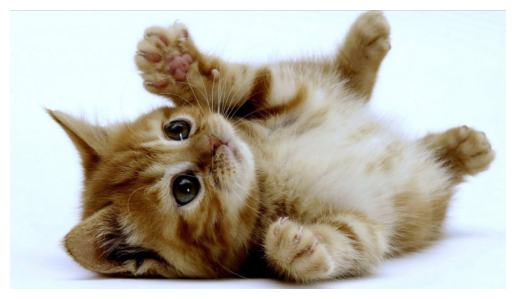

In [10]:
img_gato = cv2.imread(filename_gato)
img_gato = cv2.cvtColor(img_gato, cv2.COLOR_BGR2RGB)
plt.imshow(img_gato)
plt.axis("off")
plt.show()

In [11]:
cfg_vgg = modelo_vgg19.default_cfg
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(cfg_vgg["mean"], cfg_vgg["std"])
])

img_tensor = preprocess(img_gato)
img_batch = img_tensor.unsqueeze(0)
print(f"Dimensiones del batch de imágenes: {img_batch.shape}")

Dimensiones del batch de imágenes: torch.Size([1, 3, 224, 224])


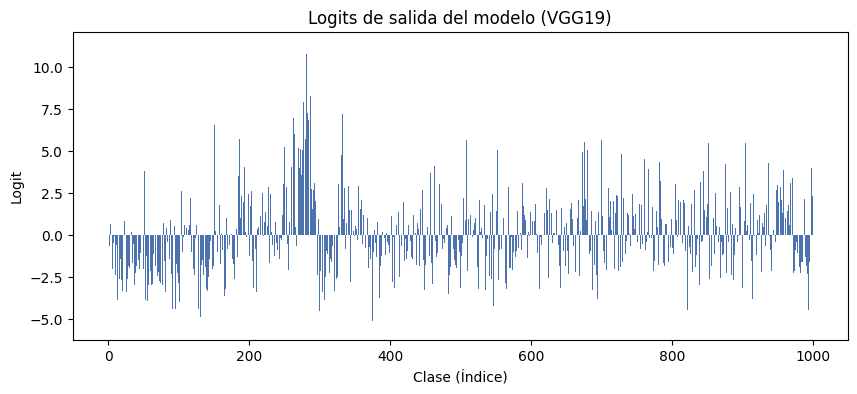

In [12]:
with torch.no_grad():
    output = modelo_vgg19(img_batch)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(1000), output.numpy().squeeze(), color='#4C72B0')
plt.title("Logits de salida del modelo (VGG19)")
plt.xlabel("Clase (Índice)")
plt.ylabel("Logit")
plt.show()

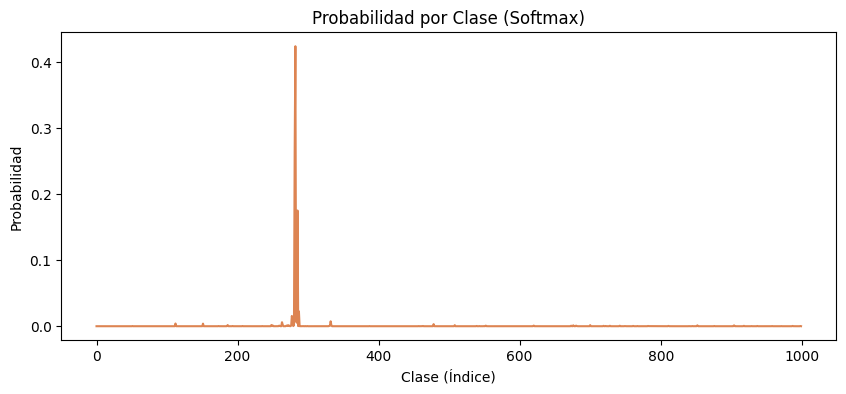

In [13]:
probabilities = torch.nn.functional.softmax(output[0], dim=0)
plt.figure(figsize=(10, 4))
plt.plot(probabilities.numpy(), color='#DD8452')
plt.title("Probabilidad por Clase (Softmax)")
plt.xlabel("Clase (Índice)")
plt.ylabel("Probabilidad")
plt.show()

In [14]:
# ============================================================
# Descarga de etiquetas de clase de ImageNet de forma autónoma
# ============================================================
url_labels = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
filename_labels = "imagenet_classes.txt"

descargar_archivo(url_labels, filename_labels)

with open(filename_labels, "r") as f:
    categories = [linea.strip() for linea in f.readlines()]

Descargando imagenet_classes.txt desde https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt...
Descarga completa de imagenet_classes.txt.


In [15]:
top5_prob, top5_catid = torch.topk(probabilities, 5)
print("Top 5 Clases Predichas para cat.jpg:")
for i in range(top5_prob.size(0)):
    print(f"  {categories[top5_catid[i].item()]}: {top5_prob[i].item():.4f}")

Top 5 Clases Predichas para cat.jpg:
  tiger cat: 0.4238
  tabby: 0.2642
  Egyptian cat: 0.1751
  lynx: 0.0224
  red fox: 0.0155


In [16]:
def evaluar_imagen_en_modelo(modelo, img, categorias_imagenet):
    cfg = modelo.default_cfg
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(cfg["mean"], cfg["std"])
    ])
    img_tensor = preprocess(img)
    img_batch = img_tensor.unsqueeze(0)
    with torch.no_grad():
        output = modelo(img_batch)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    for i in range(top5_prob.size(0)):
        print(f"  {categorias_imagenet[top5_catid[i].item()]}: {top5_prob[i].item():.4f}")

Descargando lince.jpg desde https://upload.wikimedia.org/wikipedia/commons/6/68/Lynx_lynx_poing.jpg...
Descarga completa de lince.jpg.


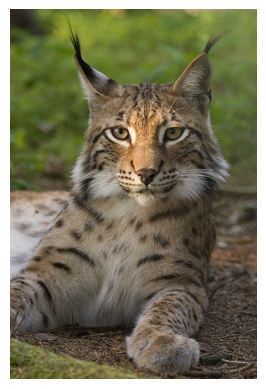

Predicciones para lince.jpg:
  lynx: 0.9995
  tiger cat: 0.0002
  leopard: 0.0001
  Egyptian cat: 0.0001
  cheetah: 0.0001


In [17]:
url_lince = "https://upload.wikimedia.org/wikipedia/commons/6/68/Lynx_lynx_poing.jpg"
filename_lince = "lince.jpg"

descargar_archivo(url_lince, filename_lince)

img_lince = cv2.imread(filename_lince)
img_lince = cv2.cvtColor(img_lince, cv2.COLOR_BGR2RGB)
plt.imshow(img_lince)
plt.axis("off")
plt.show()

print("Predicciones para lince.jpg:")
evaluar_imagen_en_modelo(modelo_vgg19, img_lince, categories)

## **1.3 Visualización de Mapas de Activación con Grad-CAM y Captum**

Las técnicas de atribuibilidad de capas como Grad-CAM nos permiten visualizar qué áreas de la imagen original influyeron más en la clasificación final.

Top 5 Clases Predichas:
  tiger cat: 0.5570
  tabby: 0.2372
  Egyptian cat: 0.0832
  Persian cat: 0.0693
  lynx: 0.0194


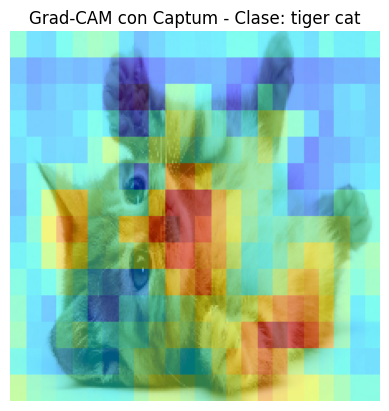

In [18]:
# ============================================================
# Visualización Grad-CAM utilizando la librería Captum
# ============================================================
def test_image_gradcam_captum(modelo, img, categorias):
    cfg = modelo.default_cfg
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(cfg["mean"], cfg["std"])
    ])
    img_tensor = preprocess(img)
    img_batch = img_tensor.unsqueeze(0)
    
    modelo.eval()
    with torch.no_grad():
        output = modelo(img_batch)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    
    print("Top 5 Clases Predichas:")
    for i in range(top5_prob.size(0)):
        print(f"  {categorias[top5_catid[i].item()]}: {top5_prob[i].item():.4f}")

    # Capa convolucional final en VGG19 (features[35])
    target_layer = modelo.features[35]

    # Crear objeto LayerGradCam
    gradcam = LayerGradCam(modelo, target_layer)
    predicted_class = output.argmax(dim=1).item()

    # Obtener atribuciones
    attributions = gradcam.attribute(img_batch, target=predicted_class)
    attributions = LayerAttribution.interpolate(attributions, (224, 224))
    attr_np = attributions.squeeze().cpu().detach().numpy()
    
    # Normalizar heatmap
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-8)

    # Mostrar original y heatmap
    plt.imshow(cv2.resize(img, (224, 224)))
    plt.imshow(attr_np, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.title(f"Grad-CAM con Captum - Clase: {categorias[predicted_class]}")
    plt.show()

test_image_gradcam_captum(modelo_vgg19, img_gato, categories)

model.safetensors:   0%|          | 0.00/260M [00:00<?, ?B/s]

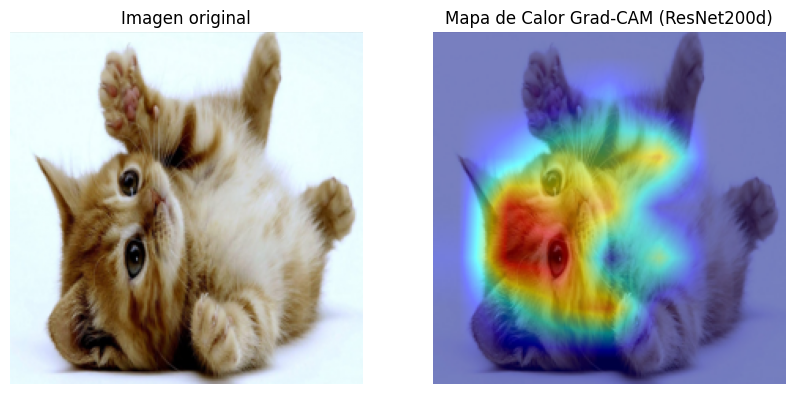

In [19]:
# ============================================================
# Grad-CAM con la librería pytorch-grad-cam sobre ResNet200d
# ============================================================
mod_resnet = timm.create_model('resnet200d', pretrained=True)
mod_resnet.eval()
mod_resnet.to(device)

# Seleccionar la capa target final de convoluciones en ResNet200d
target_layer = mod_resnet.layer4[-1].conv3

# Transformada para cargar la imagen
transform_res = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mod_resnet.default_cfg["mean"], std=mod_resnet.default_cfg["std"]),
])

pil_img = Image.open(filename_gato).convert("RGB")
input_tensor = transform_res(pil_img).unsqueeze(0).to(device)

# Instanciar GradCAM
cam = GradCAM(model=mod_resnet, target_layers=[target_layer])
grayscale_cam = cam(input_tensor=input_tensor)[0]

# Desnormalizar imagen para superponer Grad-CAM
img_normalizada = np.array(pil_img.resize((224, 224))) / 255.0
cam_image = show_cam_on_image(img_normalizada, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen original")
plt.imshow(img_normalizada)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mapa de Calor Grad-CAM (ResNet200d)")
plt.imshow(cam_image)
plt.axis('off')

plt.show()

# **2. Técnicas de Data Augmentation**

El aumento de datos (*Data Augmentation*) permite generar nuevas muestras de entrenamiento aplicando transformaciones aleatorias a las imágenes existentes, mejorando la generalización del modelo.

In [20]:
def aplicar_resize(img, imsize):
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((imsize, imsize))
    ])
    return preprocess(img)

resized_imgs = [aplicar_resize(img_gato, s) for s in [128, 32]]
print(f"Tamaño 1: {resized_imgs[0].size}")
print(f"Tamaño 2: {resized_imgs[1].size}")

Tamaño 1: (128, 128)
Tamaño 2: (32, 32)


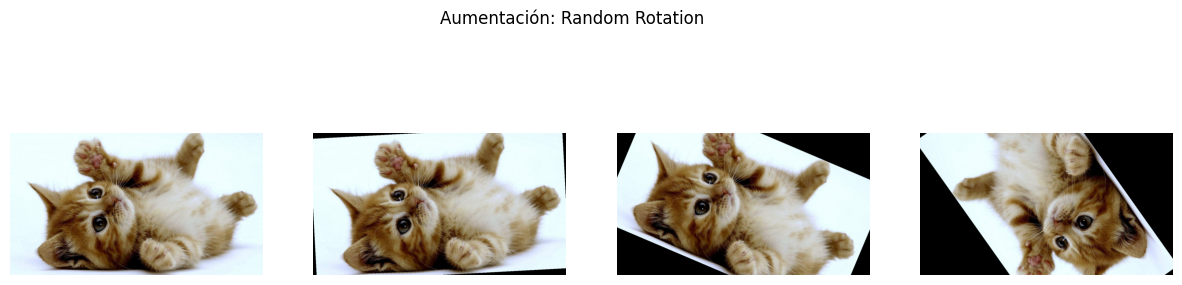

In [21]:
def aplicar_rotacion(img, degrees):
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomRotation(degrees=degrees)
    ])
    return preprocess(img)

rotated_imgs = [img_gato] + [aplicar_rotacion(img_gato, d) for d in range(50, 151, 50)]
plt.figure(figsize=(15, 4))
for idx, image in enumerate(rotated_imgs):
    plt.subplot(1, 4, idx+1)
    plt.imshow(image)
    plt.axis("off")
plt.suptitle("Aumentación: Random Rotation")
plt.show()

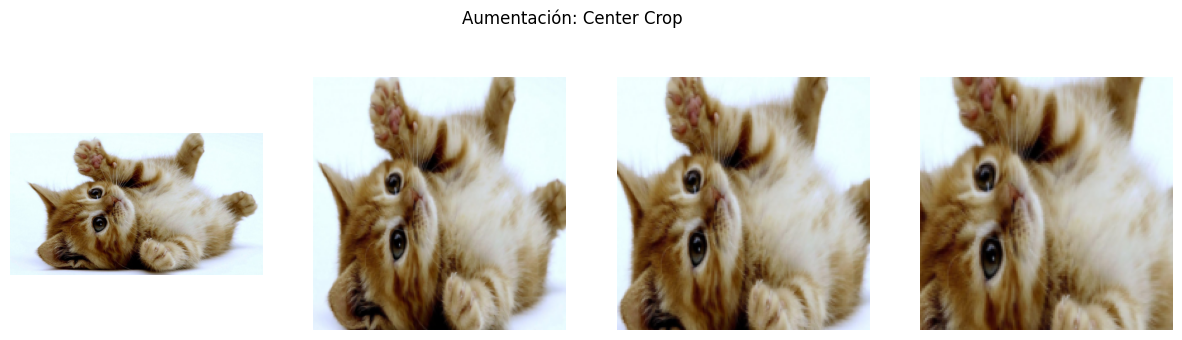

In [22]:
def aplicar_crop(img, size):
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.CenterCrop(size=size)
    ])
    return preprocess(img)

center_crops = [img_gato] + [aplicar_crop(img_gato, size) for size in (200, 180, 150)]
plt.figure(figsize=(15, 4))
for idx, image in enumerate(center_crops):
    plt.subplot(1, 4, idx+1)
    plt.imshow(image)
    plt.axis("off")
plt.suptitle("Aumentación: Center Crop")
plt.show()

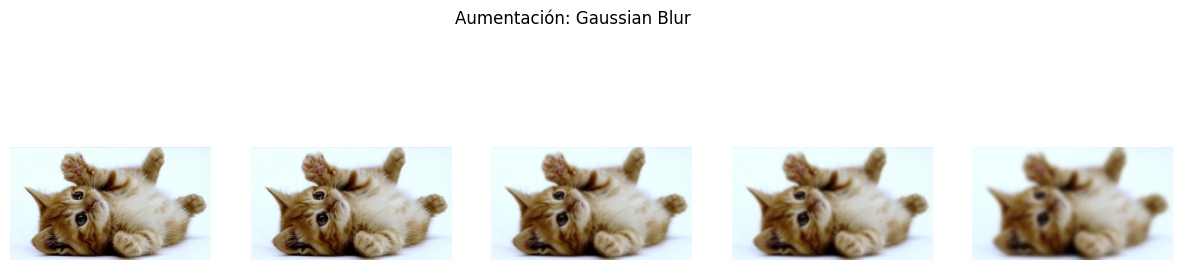

In [23]:
def aplicar_blur(img, sigma):
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.GaussianBlur(kernel_size=(51, 91), sigma=sigma)
    ])
    return preprocess(img)

blurred_imgs = [img_gato] + [aplicar_blur(img_gato, sigma) for sigma in (1, 3.3, 5, 10)]
plt.figure(figsize=(15, 4))
for idx, image in enumerate(blurred_imgs):
    plt.subplot(1, 5, idx+1)
    plt.imshow(image)
    plt.axis("off")
plt.suptitle("Aumentación: Gaussian Blur")
plt.show()

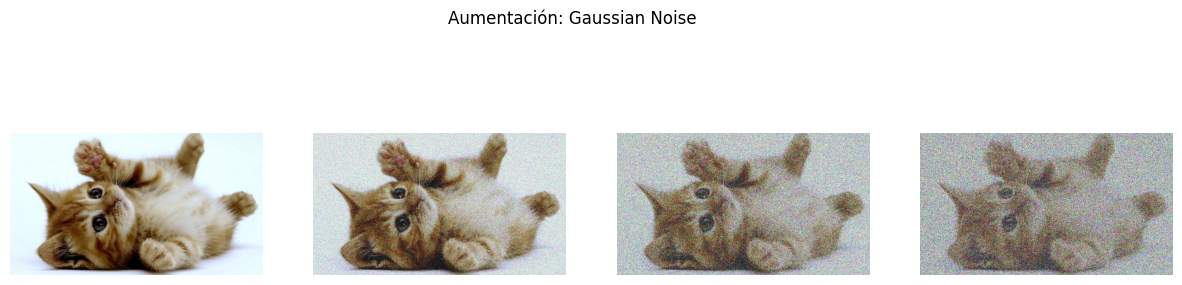

In [24]:
def agregar_ruido(img, noise_factor=0.3):
    img_tensor = transforms.ToTensor()(img)
    noisy = img_tensor + torch.randn_like(img_tensor) * noise_factor
    noisy = torch.clip(noisy, 0., 1.)
    return transforms.ToPILImage()(noisy)

noise_imgs = [img_gato] + [agregar_ruido(img_gato, nf) for nf in (0.3, 0.6, 0.9)]
plt.figure(figsize=(15, 4))
for idx, image in enumerate(noise_imgs):
    plt.subplot(1, 4, idx+1)
    plt.imshow(image)
    plt.axis("off")
plt.suptitle("Aumentación: Gaussian Noise")
plt.show()

# **3. Casos de Estudio en PyTorch Clásico: Clasificación de Flores**

Implementaremos Transfer Learning y Fine-Tuning de forma clásica utilizando bucles estándar de entrenamiento en PyTorch para clasificar imágenes en el dataset de Flores.

In [25]:
# ============================================================
# Descarga y Extracción del Dataset de Flores de Google
# ============================================================
url_flores = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
tgz_flores = "flower_photos.tgz"
carpeta_extract = "data"

if not os.path.exists(tgz_flores):
    print("Descargando dataset de flores...")
    response = requests.get(url_flores, stream=True)
    with open(tgz_flores, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Descarga completada.")

if not os.path.exists(os.path.join(carpeta_extract, "flower_photos")):
    print("Descomprimiendo archivos...")
    with tarfile.open(tgz_flores, "r:gz") as tar:
        tar.extractall(path=carpeta_extract)
    print("Descompresión completada.")

Descargando dataset de flores...
Descarga completada.
Descomprimiendo archivos...
Descompresión completada.


In [26]:
# ============================================================
# División del dataset en Entrenamiento (80%), Val (10%) y Test (10%)
# ============================================================
ruta_fotos = "data/flower_photos"
ruta_flores_experimento = "data/flower_experiments"

if not os.path.exists(ruta_flores_experimento):
    print("Dividiendo dataset en subcarpetas train, val y test...")
    splitfolders.ratio(ruta_fotos, output=ruta_flores_experimento, seed=1337, ratio=(.8, 0.1, 0.1))
    print("División completa.")

Dividiendo dataset en subcarpetas train, val y test...


Copying files: 3670 files [00:00, 4478.32 files/s]

División completa.


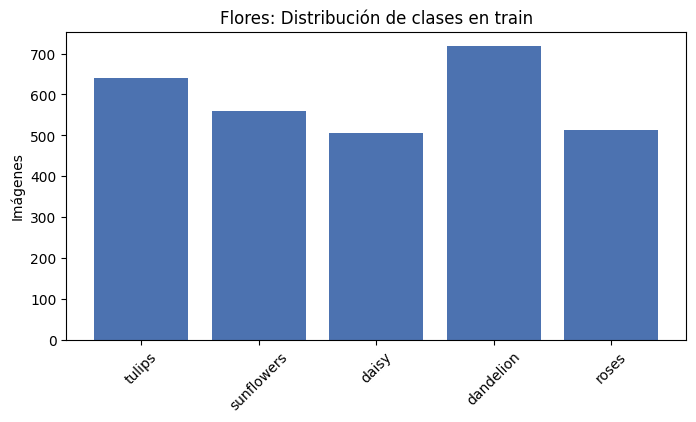

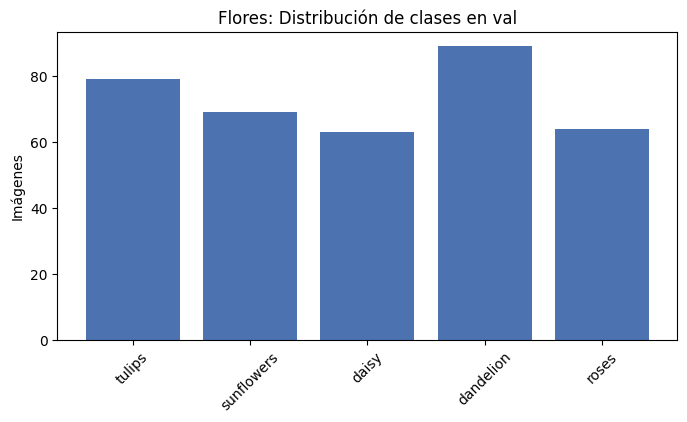

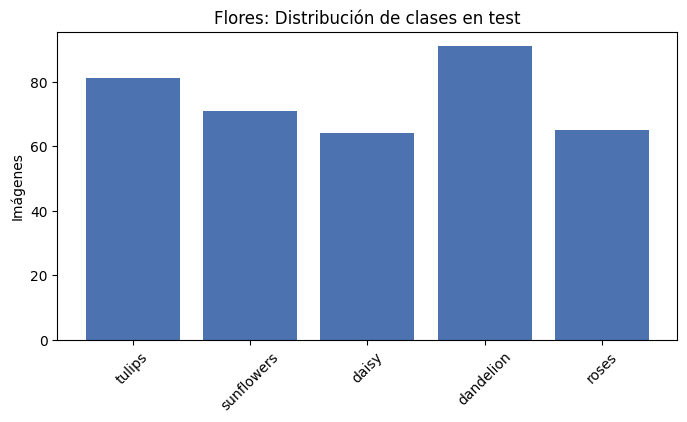

In [27]:
def mostrar_distribucion_clases(ruta_base, tipo_particion):
    ruta_completa = os.path.join(ruta_base, tipo_particion)
    directorios = [f.path for f in os.scandir(ruta_completa) if f.is_dir()]
    nombres_clases = [os.path.basename(d) for d in directorios]
    cantidades = []
    for d in directorios:
        imagenes = glob(os.path.join(d, "*.jpg"))
        cantidades.append(len(imagenes))
    
    plt.figure(figsize=(8, 4))
    plt.bar(nombres_clases, cantidades, color='#4C72B0')
    plt.title(f"Flores: Distribución de clases en {tipo_particion}")
    plt.ylabel("Imágenes")
    plt.xticks(rotation=45)
    plt.show()

mostrar_distribucion_clases(ruta_flores_experimento, "train")
mostrar_distribucion_clases(ruta_flores_experimento, "val")
mostrar_distribucion_clases(ruta_flores_experimento, "test")

In [28]:
# ============================================================
# Clase Dataset Personalizado para Flores en Español
# ============================================================
class DatasetFlores(Dataset):
    def __init__(self, dataset_carpeta, transform=None):
        self.dataset_carpeta = dataset_carpeta
        self.transform = transform

    def __getitem__(self, index):
        imagen, etiqueta = self.dataset_carpeta[index]
        if self.transform:
            imagen = self.transform(imagen)
        return imagen, etiqueta

    def __len__(self):
        return len(self.dataset_carpeta)

In [29]:
# ============================================================
# Módulo de datos para Flores en PyTorch estándar
# ============================================================
class ModuloDatosFlores:
    def __init__(self, media_desv, ruta_datos, img_size=224, batch_size=64):
        self.ruta_datos = ruta_datos
        self.img_size = img_size
        self.batch_size = batch_size

        self.transform_base = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(media_desv[0], media_desv[1])
        ])

        self.transform_entrenamiento = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.RandomRotation(degrees=15),
            transforms.CenterCrop(size=self.img_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(media_desv[0], media_desv[1])
        ])

    def setup(self):
        path_train = os.path.join(self.ruta_datos, 'train')
        path_valid = os.path.join(self.ruta_datos, 'val')
        path_test  = os.path.join(self.ruta_datos, 'test')

        folder_train = datasets.ImageFolder(root=path_train)
        folder_valid = datasets.ImageFolder(root=path_valid)
        folder_test  = datasets.ImageFolder(root=path_test)

        self.datos_entrenamiento = DatasetFlores(folder_train, self.transform_entrenamiento)
        self.datos_validacion    = DatasetFlores(folder_valid, self.transform_base)
        self.datos_prueba        = DatasetFlores(folder_test, self.transform_base)
        self.categories          = folder_test.class_to_idx

    def obtener_cargadores(self):
        cargador_train = DataLoader(self.datos_entrenamiento, batch_size=self.batch_size, shuffle=True)
        cargador_valid = DataLoader(self.datos_validacion,    batch_size=self.batch_size, shuffle=False)
        cargador_test  = DataLoader(self.datos_prueba,        batch_size=self.batch_size, shuffle=False)
        return cargador_train, cargador_valid, cargador_test

In [30]:
def guardar_modelo_clasico(modelo, path_guardado="results/TRL-vgg19"):
    os.makedirs(path_guardado, exist_ok=True)
    ruta_archivo = os.path.join(path_guardado, "NetModel.pth")
    torch.save(modelo.state_dict(), ruta_archivo)
    print(f"Modelo guardado en: {ruta_archivo}")

In [31]:
dm_flores = ModuloDatosFlores(
    media_desv=([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ruta_datos=ruta_flores_experimento,
    img_size=224,
    batch_size=64
)
dm_flores.setup()
cargador_entrenar, _, _ = dm_flores.obtener_cargadores()
for imagenes, etiquetas in cargador_entrenar:
    print(f"Dimensiones de lote de imágenes: {imagenes.shape}")
    break

Dimensiones de lote de imágenes: torch.Size([64, 3, 224, 224])


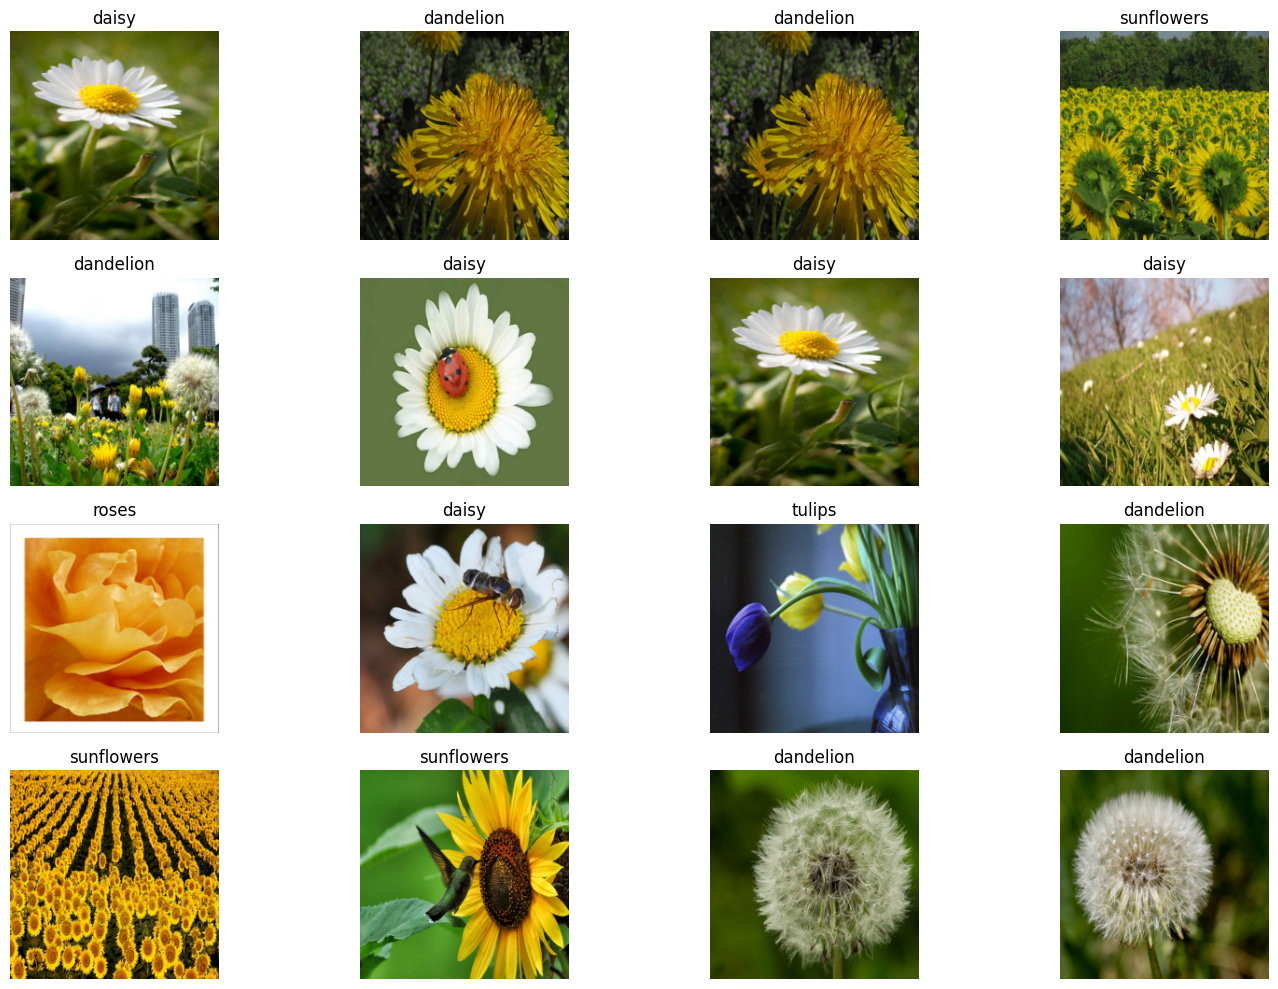

In [32]:
path_test = os.path.join(ruta_flores_experimento, 'test')
dataset_test_vis = datasets.ImageFolder(root=path_test)
dataset_visual = DatasetFlores(dataset_test_vis)
mapa_inverso = {v: k for k, v in dm_flores.categories.items()}

plt.figure(figsize=(15, 10))
for i in range(16):
    idx = np.random.randint(len(dataset_visual))
    img, etiqueta = dataset_visual[idx]
    img = transforms.Resize(size=(224, 224))(img)
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(mapa_inverso[etiqueta])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# Bucle de Entrenamiento, Validación y Prueba estándar en PyTorch
# ============================================================
def entrenar_modelo_pytorch(modelo, criterio, dispositivo, cargador_train, cargador_val, optimizador, num_epocas, porc_descongelado=0.0):
    n = len(list(modelo.parameters()))
    if porc_descongelado > 0:
        print(f"APLICANDO FINE-TUNING: Descongelando el {porc_descongelado * 100}% de las capas superiores.")
        for i, parametro in enumerate(modelo.parameters()):
            if i > n * (1.0 - porc_descongelado):
                parametro.requires_grad = True
    else:
        print("APLICANDO TRANSFER LEARNING: Entrenando únicamente la cabeza clasificadora.")

    historial = []
    mejor_f1 = 0.0

    for epoca in range(1, num_epocas + 1):
        modelo.train()
        perdida_entrenamiento = 0.0
        
        # Envolver el cargador de entrenamiento en una barra de progreso tqdm
        bucle_progreso = tqdm(
            enumerate(cargador_train),
            total=len(cargador_train),
            desc=f"Época {epoca}/{num_epocas}",
            leave=False
        )
        for batch_idx, (imagenes, etiquetas) in bucle_progreso:
            imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
            
            optimizador.zero_grad()
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida.backward()
            optimizador.step()
            
            perdida_entrenamiento += perdida.item()
            bucle_progreso.set_postfix(loss=perdida.item())

        perdida_train_media = perdida_entrenamiento / len(cargador_train)
        
        # Evaluación en validación
        perdida_val_media, f1_val = evaluar_modelo_pytorch(modelo, criterio, dispositivo, cargador_val)
        historial.append((perdida_train_media, perdida_val_media, f1_val))

        print(f"Época [{epoca}/{num_epocas}] | Pérdida Train: {perdida_train_media:.4f} | Pérdida Val: {perdida_val_media:.4f} | F1-Macro Val: {f1_val:.4f}")

        if f1_val > mejor_f1:
            print(f"  F1-Macro incrementado ({mejor_f1:.4f} ---> {f1_val:.4f}) | Guardando mejor checkpoint...")
            guardar_modelo_clasico(modelo)
            mejor_f1 = f1_val

    return modelo, historial

def evaluar_modelo_pytorch(modelo, criterio, dispositivo, cargador_val):
    modelo.eval()
    perdida_validacion = 0.0
    todas_predicciones = []
    todas_etiquetas = []

    with torch.no_grad():
        for imagenes, etiquetas in cargador_val:
            imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_validacion += perdida.item()
            
            predicciones = salidas.argmax(dim=1)
            todas_predicciones.extend(predicciones.cpu().numpy())
            todas_etiquetas.extend(etiquetas.cpu().numpy())

    perdida_val_media = perdida_validacion / len(cargador_val)
    f1_val = f1_score(todas_etiquetas, todas_predicciones, average='macro', zero_division=0)
    return perdida_val_media, f1_val


In [34]:
def probar_modelo_pytorch(modelo, criterio, dispositivo, cargador_test):
    modelo.eval()
    perdida_test = 0.0
    predicciones_totales = torch.tensor([]).to(dispositivo)
    etiquetas_totales = torch.tensor([]).to(dispositivo)

    with torch.no_grad():
        for imagenes, etiquetas in cargador_test:
            imagenes, etiquetas = imagenes.to(dispositivo), etiquetas.to(dispositivo)
            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)
            perdida_test += perdida.item()
            
            predicciones_totales = torch.cat((predicciones_totales, salidas), dim=0)
            etiquetas_totales = torch.cat((etiquetas_totales, etiquetas), dim=0)

    perdida_test_media = perdida_test / len(cargador_test)
    y_verdadero = etiquetas_totales.cpu().numpy()
    y_predicho = predicciones_totales.argmax(dim=1).cpu().numpy()
    
    print(f"Pérdida en Test: {perdida_test_media:.4f}")
    return y_predicho, y_verdadero

In [35]:
# ============================================================
# Arquitectura VGG19 adaptada para Transfer Learning (Flores)
# ============================================================
class ModeloVGG19(nn.Module):
    def __init__(self, num_clases=5, preentrenado=True):
        super().__init__()
        self.num_clases = num_clases
        self.vgg = timm.create_model("vgg19", pretrained=preentrenado)

        if preentrenado:
            # Congelar extractor de características
            for param in self.vgg.parameters():
                param.requires_grad = False

        # Nueva cabeza clasificadora para 5 clases
        num_caracteristicas = self.vgg.get_classifier().in_features
        bloque_fc = nn.Sequential(
            nn.Linear(num_caracteristicas, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_clases)
        )
        self.vgg.head.fc = bloque_fc

    def forward(self, x):
        return self.vgg(x)

    def get_mean_std(self):
        return self.vgg.default_cfg["mean"], self.vgg.default_cfg["std"]

In [36]:
num_clases = 5
lr = 1e-4
num_epocas = 5  # Suficiente para validación rápida
batch_size = 64
img_size = 224
criterio = nn.CrossEntropyLoss().to(device)

In [37]:
modelo_vgg_transfer = ModeloVGG19(num_clases=num_clases).to(device)
optimizador = optim.Adam(modelo_vgg_transfer.parameters(), lr=lr)

dm_flores_vgg = ModuloDatosFlores(
    media_desv=modelo_vgg_transfer.get_mean_std(),
    ruta_datos=ruta_flores_experimento,
    img_size=img_size,
    batch_size=batch_size
)
dm_flores_vgg.setup()
cargador_train, cargador_valid, cargador_test = dm_flores_vgg.obtener_cargadores()

In [38]:
modelo_vgg_transfer, historial_vgg = entrenar_modelo_pytorch(
    modelo_vgg_transfer, criterio, device, cargador_train, cargador_valid, optimizador, num_epocas
)

APLICANDO TRANSFER LEARNING: Entrenando únicamente la cabeza clasificadora.


Época 1/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [1/5] | Pérdida Train: 0.7905 | Pérdida Val: 0.4799 | F1-Macro Val: 0.7885
  F1-Macro incrementado (0.0000 ---> 0.7885) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 2/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [2/5] | Pérdida Train: 0.4567 | Pérdida Val: 0.3866 | F1-Macro Val: 0.8385
  F1-Macro incrementado (0.7885 ---> 0.8385) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


...

Época [3/5] | Pérdida Train: 0.3933 | Pérdida Val: 0.4235 | F1-Macro Val: 0.8271


Época 4/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [4/5] | Pérdida Train: 0.3627 | Pérdida Val: 0.3656 | F1-Macro Val: 0.8589
  F1-Macro incrementado (0.8385 ---> 0.8589) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 5/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [5/5] | Pérdida Train: 0.3184 | Pérdida Val: 0.3619 | F1-Macro Val: 0.8750
  F1-Macro incrementado (0.8589 ---> 0.8750) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


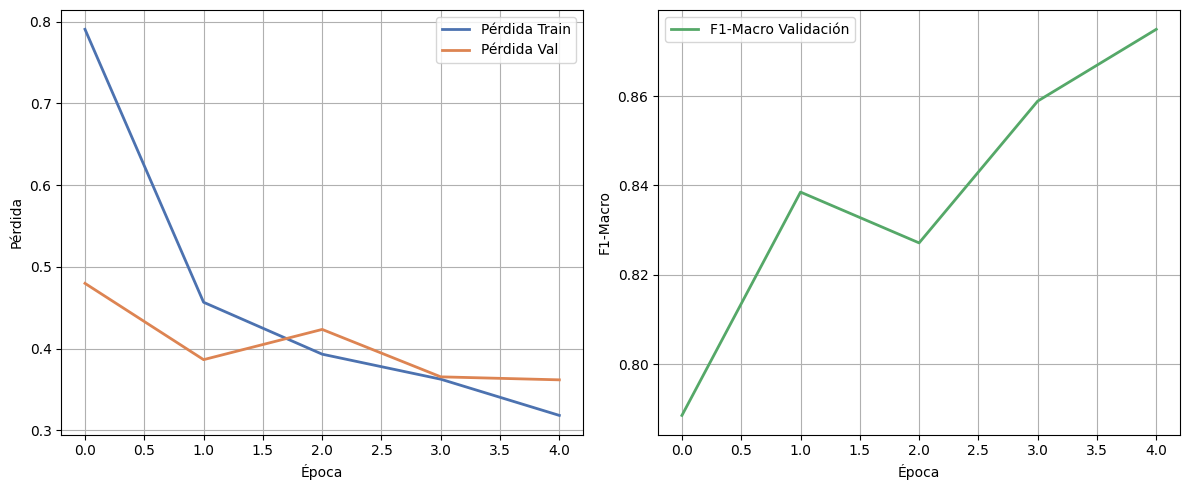

In [39]:
def graficar_curvas_aprendizaje_clasicas(historial, epocas):
    arr = np.array(historial)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(arr[:, 0], label="Pérdida Train", linewidth=2, color='#4C72B0')
    plt.plot(arr[:, 1], label="Pérdida Val", linewidth=2, color='#DD8452')
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(arr[:, 2], label="F1-Macro Validación", linewidth=2, color='#55A868')
    plt.xlabel("Época")
    plt.ylabel("F1-Macro")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

graficar_curvas_aprendizaje_clasicas(historial_vgg, num_epocas)

In [40]:
# Cargar mejor checkpoint y correr predicciones en el test dataloader
modelo_sv = ModeloVGG19(num_clases=num_clases).to(device)
modelo_sv.load_state_dict(torch.load("results/TRL-vgg19/NetModel.pth"))

dm_test_vgg = ModuloDatosFlores(
    media_desv=modelo_sv.get_mean_std(),
    ruta_datos=ruta_flores_experimento,
    img_size=img_size,
    batch_size=1
)
dm_test_vgg.setup()
_, _, cargador_test_vgg = dm_test_vgg.obtener_cargadores()

y_pred, y_true = probar_modelo_pytorch(modelo_sv, criterio, device, cargador_test_vgg)
nombres_clases = list(dm_test_vgg.categories.keys())

Pérdida en Test: 0.3869


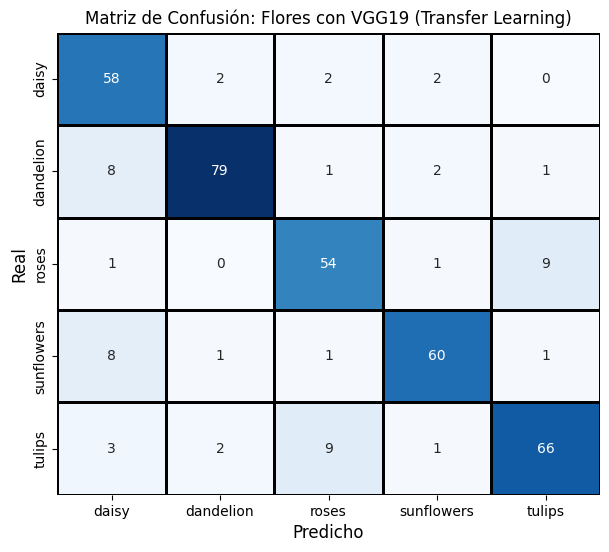

In [41]:
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=nombres_clases, columns=nombres_clases)

plt.figure(figsize=(7, 6))
sns.heatmap(df_cm, annot=True, cbar=False, cmap='Blues', fmt='d', linewidths=1, linecolor='black')
plt.xlabel('Predicho', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title("Matriz de Confusión: Flores con VGG19 (Transfer Learning)")
plt.show()

In [42]:
print("Reporte de Clasificación (VGG19 Transfer Learning):")
print(classification_report(y_true, y_pred, target_names=nombres_clases, zero_division=0))

Reporte de Clasificación (VGG19 Transfer Learning):
              precision    recall  f1-score   support

       daisy       0.74      0.91      0.82        64
   dandelion       0.94      0.87      0.90        91
       roses       0.81      0.83      0.82        65
  sunflowers       0.91      0.85      0.88        71
      tulips       0.86      0.81      0.84        81

    accuracy                           0.85       372
   macro avg       0.85      0.85      0.85       372
weighted avg       0.86      0.85      0.85       372



## **3.5 Fine-Tuning con VGG19**

Descongelamos el 25% de las capas convolucionales superiores de la red VGG19 para entrenar en conjunto con la cabeza clasificadora a una tasa de aprendizaje reducida.

In [43]:
lr_fine = 1e-5
num_epocas_fine = 3

optimizador_fine = optim.Adam(modelo_sv.parameters(), lr=lr_fine)
modelo_sv, _ = entrenar_modelo_pytorch(
    modelo_sv, criterio, device, cargador_train, cargador_valid, optimizador_fine, num_epocas_fine, porc_descongelado=0.25
)

APLICANDO FINE-TUNING: Descongelando el 25.0% de las capas superiores.


Época 1/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época [1/3] | Pérdida Train: 0.2818 | Pérdida Val: 0.3787 | F1-Macro Val: 0.8633
  F1-Macro incrementado (0.0000 ---> 0.8633) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 2/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época [2/3] | Pérdida Train: 0.2110 | Pérdida Val: 0.3590 | F1-Macro Val: 0.8714
  F1-Macro incrementado (0.8633 ---> 0.8714) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 3/3:   0%|          | 0/46 [00:00<?, ?it/s]

Época [3/3] | Pérdida Train: 0.1853 | Pérdida Val: 0.3604 | F1-Macro Val: 0.8838
  F1-Macro incrementado (0.8714 ---> 0.8838) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


In [44]:
y_pred_fine, y_true_fine = probar_modelo_pytorch(modelo_sv, criterio, device, cargador_test_vgg)
print("Reporte de Clasificación Flores (Fine-Tuning VGG19):")
print(classification_report(y_true_fine, y_pred_fine, target_names=nombres_clases, zero_division=0))

Pérdida en Test: 0.3563
Reporte de Clasificación Flores (Fine-Tuning VGG19):
              precision    recall  f1-score   support

       daisy       0.80      0.92      0.86        64
   dandelion       0.98      0.89      0.93        91
       roses       0.84      0.82      0.83        65
  sunflowers       0.91      0.85      0.88        71
      tulips       0.85      0.90      0.87        81

    accuracy                           0.88       372
   macro avg       0.87      0.87      0.87       372
weighted avg       0.88      0.88      0.88       372



## **3.6 Transfer Learning y Fine-Tuning con ResNet200d**

Repetimos la clasificación de flores pero esta vez utilizando un modelo ResNet200d preentrenado.

In [45]:
# ============================================================
# Modelo ResNet200d personalizado para PyTorch clásico (Flores)
# ============================================================
class ModeloResNet200(nn.Module):
    def __init__(self, num_clases=5, preentrenado=True):
        super().__init__()
        self.num_clases = num_clases
        self.resnet = timm.create_model("resnet200d", pretrained=preentrenado)

        if preentrenado:
            # Congelar extractor
            for param in self.resnet.parameters():
                param.requires_grad = False

        # Nueva capa totalmente conectada
        num_caracteristicas = self.resnet.get_classifier().in_features
        bloque_fc = nn.Sequential(
            nn.Linear(num_caracteristicas, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_clases)
        )
        self.resnet.fc = bloque_fc

    def forward(self, x):
        return self.resnet(x)

    def get_mean_std(self):
        return self.resnet.default_cfg["mean"], self.resnet.default_cfg["std"]

In [46]:
modelo_resnet_flores = ModeloResNet200(num_clases=num_clases).to(device)
optimizador_resnet = optim.Adam(modelo_resnet_flores.parameters(), lr=lr)

dm_flores_resnet = ModuloDatosFlores(
    media_desv=modelo_resnet_flores.get_mean_std(),
    ruta_datos=ruta_flores_experimento,
    img_size=img_size,
    batch_size=batch_size
)
dm_flores_resnet.setup()
cargador_train_res, cargador_valid_res, _ = dm_flores_resnet.obtener_cargadores()

In [47]:
modelo_resnet_flores, historial_resnet = entrenar_modelo_pytorch(
    modelo_resnet_flores, criterio, device, cargador_train_res, cargador_valid_res, optimizador_resnet, num_epocas
)

APLICANDO TRANSFER LEARNING: Entrenando únicamente la cabeza clasificadora.


Época 1/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [1/5] | Pérdida Train: 1.1438 | Pérdida Val: 0.6465 | F1-Macro Val: 0.8667
  F1-Macro incrementado (0.0000 ---> 0.8667) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 2/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [2/5] | Pérdida Train: 0.5105 | Pérdida Val: 0.3667 | F1-Macro Val: 0.8662


...

Época [3/5] | Pérdida Train: 0.3560 | Pérdida Val: 0.3058 | F1-Macro Val: 0.8782
  F1-Macro incrementado (0.8667 ---> 0.8782) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 4/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [4/5] | Pérdida Train: 0.2998 | Pérdida Val: 0.2616 | F1-Macro Val: 0.9020
  F1-Macro incrementado (0.8782 ---> 0.9020) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


Época 5/5:   0%|          | 0/46 [00:00<?, ?it/s]

Época [5/5] | Pérdida Train: 0.2583 | Pérdida Val: 0.2555 | F1-Macro Val: 0.9045
  F1-Macro incrementado (0.9020 ---> 0.9045) | Guardando mejor checkpoint...
Modelo guardado en: results/TRL-vgg19/NetModel.pth


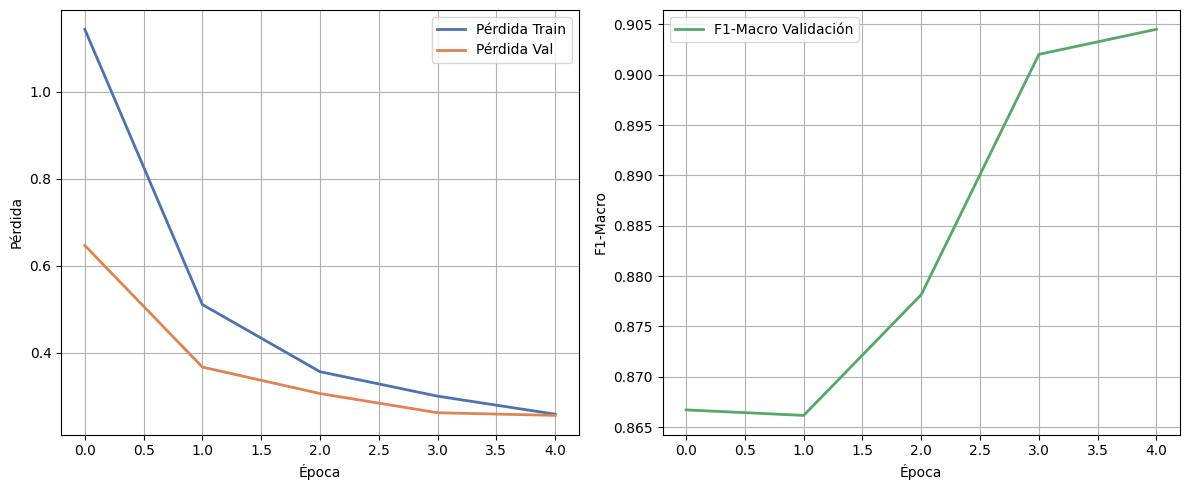

In [48]:
graficar_curvas_aprendizaje_clasicas(historial_resnet, num_epocas)

In [49]:
dm_test_resnet = ModuloDatosFlores(
    media_desv=modelo_resnet_flores.get_mean_std(),
    ruta_datos=ruta_flores_experimento,
    img_size=img_size,
    batch_size=1
)
dm_test_resnet.setup()
_, _, cargador_test_resnet = dm_test_resnet.obtener_cargadores()

y_pred_res, y_true_res = probar_modelo_pytorch(modelo_resnet_flores, criterio, device, cargador_test_resnet)
print("Reporte de Clasificación (ResNet200d Flores):")
print(classification_report(y_true_res, y_pred_res, target_names=nombres_clases, zero_division=0))

Pérdida en Test: 0.2758
Reporte de Clasificación (ResNet200d Flores):
              precision    recall  f1-score   support

       daisy       0.98      0.86      0.92        64
   dandelion       0.95      0.90      0.93        91
       roses       0.91      0.89      0.90        65
  sunflowers       0.89      0.96      0.93        71
      tulips       0.86      0.95      0.90        81

    accuracy                           0.91       372
   macro avg       0.92      0.91      0.91       372
weighted avg       0.92      0.91      0.91       372



# **4. Transfer Learning con PyTorch Lightning: Cats & Dogs**

En esta sección implementaremos Transfer Learning utilizando PyTorch Lightning sobre el dataset Cats & Dogs Filtered.

In [50]:
# ============================================================
# Descarga del dataset Cats & Dogs Filtered desde el mirror MLCC
# ============================================================
url_catsdogs = "https://download.mlcc.google.com/mledu-datasets/cats_and_dogs_filtered.zip"
zip_catsdogs = "cats_and_dogs_filtered.zip"

descargar_archivo(url_catsdogs, zip_catsdogs)

if not os.path.exists("data/cats_and_dogs_filtered"):
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(zip_catsdogs, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Descompresión completada.")

Descargando cats_and_dogs_filtered.zip desde https://download.mlcc.google.com/mledu-datasets/cats_and_dogs_filtered.zip...
Descarga completa de cats_and_dogs_filtered.zip.
Descomprimiendo dataset...
Descompresión completada.


In [51]:
# ============================================================
# Clases Dataset y DataModule Lightning para Mascotas
# ============================================================
class DatasetMascotas(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        img, etiqueta = self.dataset[index]
        if self.transform:
            img = self.transform(img)
        return img, etiqueta

    def __len__(self):
        return len(self.dataset)

class ModuloDatosMascotas(pl.LightningDataModule):
    def __init__(self, data_dir: str, img_size=224, batch_size=64, media_desv=([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])):
        super().__init__()
        self.data_dir = data_dir
        self.img_size = img_size
        self.batch_size = batch_size

        self.test_transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(media_desv[0], media_desv[1])
        ])

        self.train_transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.RandomRotation(degrees=10),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(media_desv[0], media_desv[1])
        ])

    def setup(self, stage=None):
        path_train = os.path.join(self.data_dir, 'train')
        path_test  = os.path.join(self.data_dir, 'validation')

        mydataset_train = datasets.ImageFolder(root=path_train)
        mydataset_test  = datasets.ImageFolder(root=path_test)
        self.categories = mydataset_test.class_to_idx

        traindataset = DatasetMascotas(mydataset_train, self.train_transform)
        self.testdataset  = DatasetMascotas(mydataset_test,  self.test_transform)

        # Partición en entrenamiento (90%) y validación (10%)
        train_size = 0.9
        num_train = len(mydataset_train)
        indices = list(range(num_train))
        split = int(np.floor(train_size * num_train))
        np.random.shuffle(indices)

        self.traindata = torch.utils.data.Subset(traindataset, indices=indices[:split])
        self.validdata = torch.utils.data.Subset(traindataset, indices=indices[split:])

    def train_dataloader(self):
        return DataLoader(self.traindata, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.validdata, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.testdataset, batch_size=self.batch_size, shuffle=False)

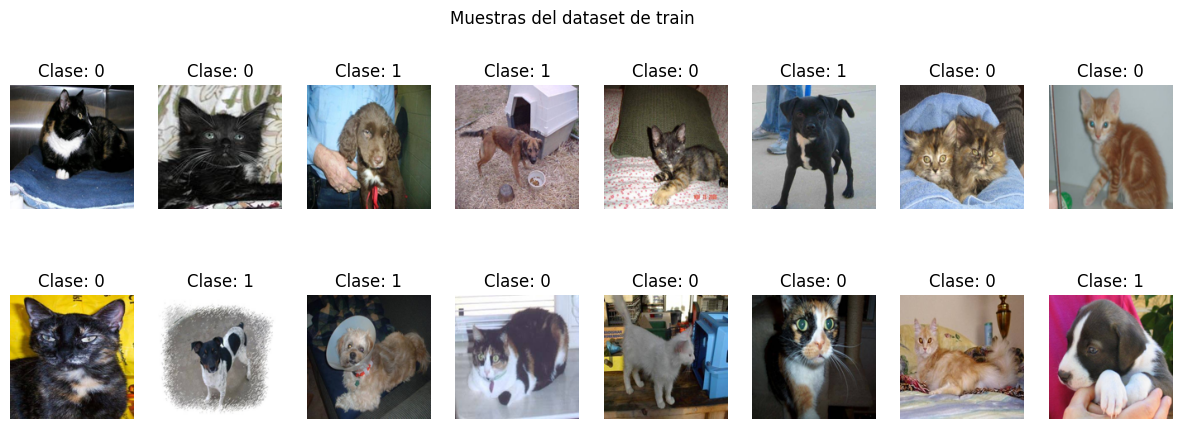

In [52]:
def mostrar_muestras_mascotas(data_path, particion, c=8, r=2):
    fig = plt.figure(figsize=(15, 5))
    ruta = os.path.join(data_path, particion)
    dataset_original = datasets.ImageFolder(root=ruta)
    for i in range(1, c*r + 1):
        idx = torch.randint(len(dataset_original), size=(1,)).item()
        img, etiqueta = dataset_original[idx]
        img = img.resize((150, 150))
        fig.add_subplot(r, c, i)
        plt.title(f"Clase: {etiqueta}")
        plt.axis("off")
        plt.imshow(img)
    plt.suptitle(f"Muestras del dataset de {particion}")
    plt.show()

base_dir_pets = "data/cats_and_dogs_filtered"
mostrar_muestras_mascotas(base_dir_pets, "train")

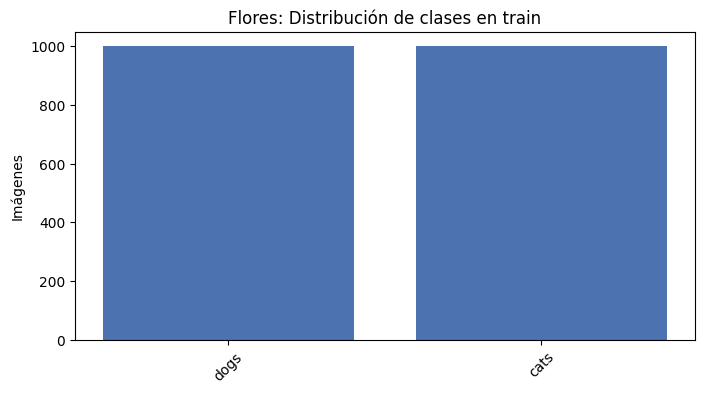

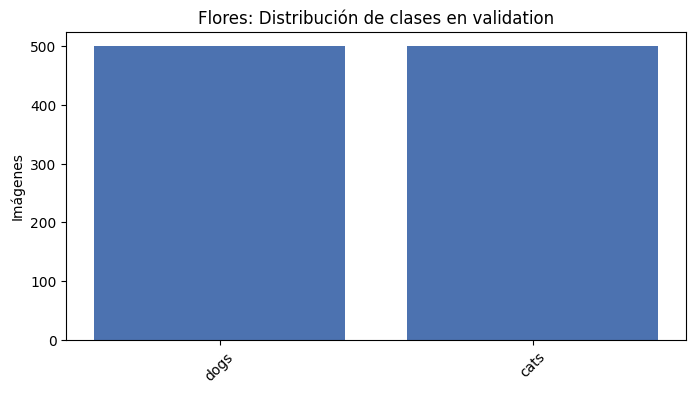

In [53]:
mostrar_distribucion_clases(base_dir_pets, "train")
mostrar_distribucion_clases(base_dir_pets, "validation")

In [54]:
# ============================================================
# Modelo ResNet200d en Lightning (ResNet200Lightning)
# ============================================================
class ResNet200Lightning(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3, preentrenado=True):
        super().__init__()
        self.num_classes = num_classes
        self.lr = lr
        
        # Historial de métricas para graficar curvas de aprendizaje
        self.historial_perdida_entrenamiento = []
        self.historial_f1_entrenamiento = []
        self.historial_perdida_validacion = []
        self.historial_f1_validacion = []
        self.perdidas_entrenamiento_lote = []
        self.perdidas_validacion_lote = []

        self.backbone = timm.create_model("resnet200d", pretrained=preentrenado)
        if preentrenado:
            for param in self.backbone.parameters():
                param.requires_grad = False

        num_caracteristicas = self.backbone.get_classifier().in_features
        bloque_fc = nn.Sequential(
            nn.Linear(num_caracteristicas, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes)
        )
        self.backbone.fc = bloque_fc

        self.loss = nn.CrossEntropyLoss()
        self.train_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.valid_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.test_f1  = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")

    def forward(self, x):
        return self.backbone(x)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        outputs = self(images)
        loss = self.loss(outputs, targets)
        preds = torch.argmax(outputs, dim=1)
        self.train_f1(preds, targets)
        
        self.perdidas_entrenamiento_lote.append(loss.detach())
        self.log('train_loss', loss, on_step=False, on_epoch=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        avg_loss = torch.stack(self.perdidas_entrenamiento_lote).mean().item()
        f1 = self.train_f1.compute().item()
        self.historial_perdida_entrenamiento.append(avg_loss)
        self.historial_f1_entrenamiento.append(f1)
        self.perdidas_entrenamiento_lote.clear()
        self.train_f1.reset()
        print(f"Época {self.current_epoch}: train_loss={avg_loss:.4f}, train_f1={f1:.4f}", end=" | ")

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        outputs = self(images)
        loss = self.loss(outputs, targets)
        preds = torch.argmax(outputs, dim=1)
        self.valid_f1(preds, targets)
        
        self.perdidas_validacion_lote.append(loss.detach())
        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.log('val_f1', self.valid_f1, on_step=False, on_epoch=True)
        return loss

    def on_validation_epoch_end(self):
        if not self.perdidas_validacion_lote:
            return
        avg_loss = torch.stack(self.perdidas_validacion_lote).mean().item()
        f1 = self.valid_f1.compute().item()
        self.historial_perdida_validacion.append(avg_loss)
        self.historial_f1_validacion.append(f1)
        self.perdidas_validacion_lote.clear()
        self.valid_f1.reset()
        print(f"val_loss={avg_loss:.4f}, val_f1={f1:.4f}")

    def test_step(self, batch, batch_idx):
        images, targets = batch
        outputs = self(images)
        loss = self.loss(outputs, targets)
        preds = torch.argmax(outputs, dim=1)
        self.test_f1(preds, targets)
        self.log('test_loss', loss)
        self.log('test_f1', self.test_f1)
        return loss

    def on_test_epoch_end(self):
        self.log('avg_test_f1', self.test_f1.compute())

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        lr_scheduler = {
            "scheduler": ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5),
            "monitor": "val_f1",
            "interval": "epoch"
        }
        return {"optimizer": optimizer, "lr_scheduler": lr_scheduler}

    def get_mean_std(self):
        return self.backbone.default_cfg["mean"], self.backbone.default_cfg["std"]

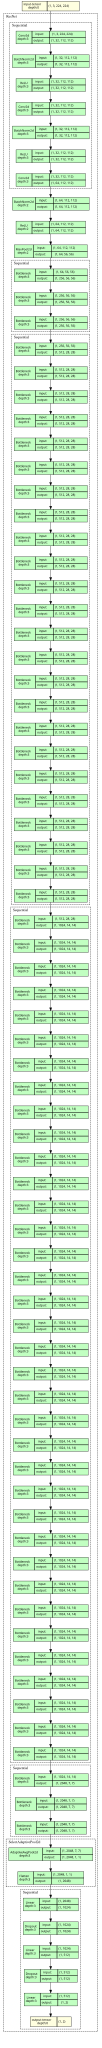

In [55]:
model_graph = draw_graph(ResNet200Lightning(), input_size=(1, 3, 224, 224), expand_nested=True)
model_graph.visual_graph

In [56]:
seed_everything(42, workers=True)

def proceso_entrenamiento_lightning(modelo, num_epocas, img_size, batch_size, data_dir, porc_fine_tuning=0.0):
    callback_model_checkpoint = ModelCheckpoint(
        filename='{epoch}-{val_f1:.3f}',
        monitor='val_f1',
        mode='max',
        dirpath="results/cats_dogs_checkpoint"
    )
    early_stop = EarlyStopping(monitor="val_f1", mode="max", patience=15, verbose=True)
    dm = ModuloDatosMascotas(data_dir=data_dir, img_size=img_size, batch_size=batch_size, media_desv=modelo.get_mean_std())

    # Desactivamos progress bar para evitar RecursionError en entornos interactivos
    trainer = Trainer(
        fast_dev_run=False,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        log_every_n_steps=5,
        max_epochs=num_epocas,
        callbacks=[callback_model_checkpoint, early_stop],
        enable_progress_bar=False
    )

    if porc_fine_tuning > 0:
        print(f"APLICANDO FINE-TUNING: Descongelando el {porc_fine_tuning * 100}% de las capas.")
        n = len(list(modelo.backbone.parameters()))
        for i, param in enumerate(modelo.backbone.parameters()):
            if i > n * (1.0 - porc_fine_tuning):
                param.requires_grad = True
    else:
        print("APLICANDO TRANSFER LEARNING: Entrenando bloque FC final.")

    trainer.fit(modelo, dm)
    trainer.test(modelo, dm)
    return modelo, callback_model_checkpoint.best_model_path

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [57]:
gc.collect()
torch.cuda.empty_cache()

num_clases_pets = 2
num_epocas_pets = 10
batch_size_pets = 64
img_size_pets   = 224
lr_pets         = 1e-3

modelo_resnet_lightning = ResNet200Lightning(num_classes=num_clases_pets, lr=lr_pets)
modelo_resnet_lightning, best_model_path_pets = proceso_entrenamiento_lightning(
    modelo_resnet_lightning, num_epocas_pets, img_size_pets, batch_size_pets, base_dir_pets
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


APLICANDO TRANSFER LEARNING: Entrenando bloque FC final.


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ ResNet            │ 65.3 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ train_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ valid_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 4 │ test_f1  │ MulticlassF1Score │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 62.6 M                                                                                       
Total params: 65.3 M                                                                                               
Total estimated model params size (MB): 261.072                                                                    
Modules in train mode: 837                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

val_loss=0.0033, val_f1=1.0000
Época 0: train_loss=0.1803, train_f1=0.9139 | val_loss=0.0123, val_f1=0.9900
Época 1: train_loss=0.0486, train_f1=0.9806 | val_loss=0.0039, val_f1=1.0000
Época 2: train_loss=0.0203, train_f1=0.9917 | val_loss=0.0198, val_f1=0.9900
Época 3: train_loss=0.0454, train_f1=0.9839 | val_loss=0.0037, val_f1=1.0000
Época 4: train_loss=0.0367, train_f1=0.9850 | val_loss=0.0204, val_f1=0.9900
Época 5: train_loss=0.0189, train_f1=0.9933 | val_loss=0.0150, val_f1=0.9950
Época 6: train_loss=0.0312, train_f1=0.9900 | val_loss=0.0214, val_f1=0.9900
Época 7: train_loss=0.0301, train_f1=0.9894 | val_loss=0.0013, val_f1=1.0000
Época 8: train_loss=0.0166, train_f1=0.9950 | 

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


val_loss=0.0078, val_f1=0.9950
Época 9: train_loss=0.0158, train_f1=0.9950 | 

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        avg_test_f1        │    0.9919998645782471     │
│          test_f1          │    0.9919998645782471     │
│         test_loss         │   0.031202388927340508    │
└───────────────────────────┴───────────────────────────┘

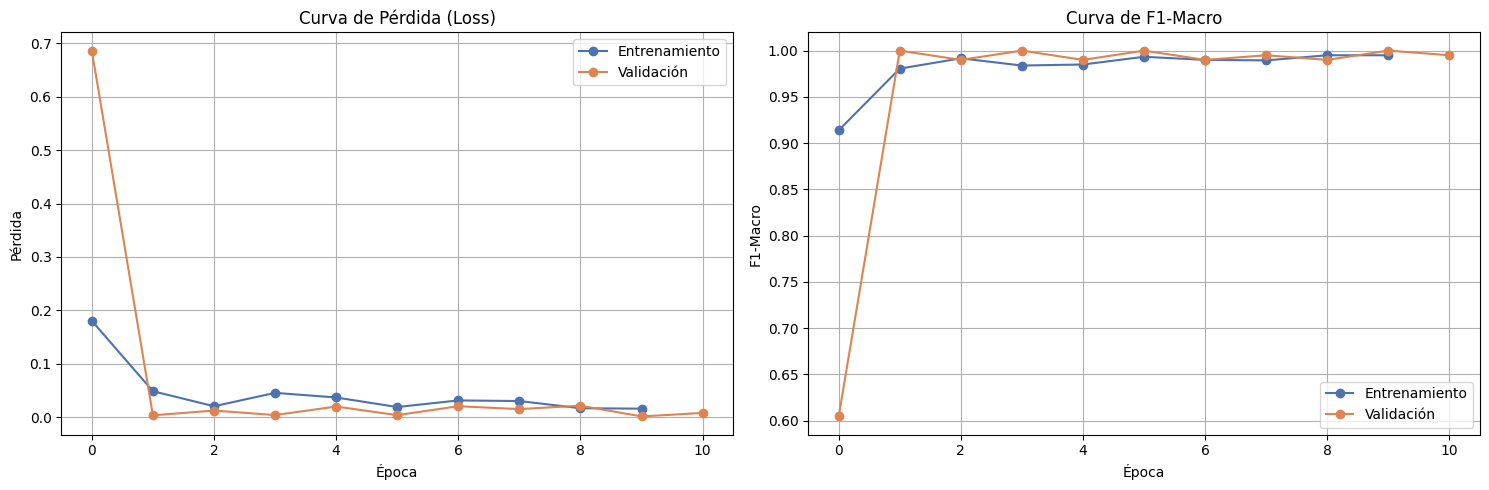

In [58]:
def graficar_curvas_aprendizaje_lightning(modelo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Pérdida (Loss)
    ax1.plot(modelo.historial_perdida_entrenamiento, label='Entrenamiento', color='#4C72B0', marker='o')
    ax1.plot(modelo.historial_perdida_validacion, label='Validación', color='#DD8452', marker='o')
    ax1.set_title('Curva de Pérdida (Loss)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True)
    
    # Exactitud (Accuracy)
    ax2.plot(modelo.historial_f1_entrenamiento, label='Entrenamiento', color='#4C72B0', marker='o')
    ax2.plot(modelo.historial_f1_validacion, label='Validación', color='#DD8452', marker='o')
    ax2.set_title('Curva de F1-Macro')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('F1-Macro')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

graficar_curvas_aprendizaje_lightning(modelo_resnet_lightning)

In [59]:
@torch.no_grad()
def obtener_todas_predicciones(modelo, loader):
    modelo.eval()
    predicciones_totales = torch.tensor([]).to(device)
    etiquetas_totales    = torch.tensor([]).to(device)

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = modelo(x)
        predicciones_totales = torch.cat((predicciones_totales, preds), dim=0)
        etiquetas_totales    = torch.cat((etiquetas_totales, y), dim=0)
    return predicciones_totales, etiquetas_totales

In [60]:
modelo_resnet_eval = ResNet200Lightning.load_from_checkpoint(best_model_path_pets, num_classes=num_clases_pets, lr=lr_pets)

dm_test_pets = ModuloDatosMascotas(
    data_dir=base_dir_pets, img_size=img_size_pets, batch_size=1, media_desv=modelo_resnet_eval.get_mean_std()
)
dm_test_pets.setup()
loader_test_pets = dm_test_pets.test_dataloader()

predicciones, etiquetas = obtener_todas_predicciones(modelo_resnet_eval.to(device), loader_test_pets)
y_true_pets = etiquetas.cpu().numpy()
y_pred_pets = predicciones.argmax(dim=1).cpu().numpy()
nombres_clases_pets = list(dm_test_pets.categories.keys())

print("Reporte de Clasificación (ResNet200d en Mascotas):")
print(classification_report(y_true_pets, y_pred_pets, target_names=nombres_clases_pets, zero_division=0))

Reporte de Clasificación (ResNet200d en Mascotas):
              precision    recall  f1-score   support

        cats       0.99      0.99      0.99       500
        dogs       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



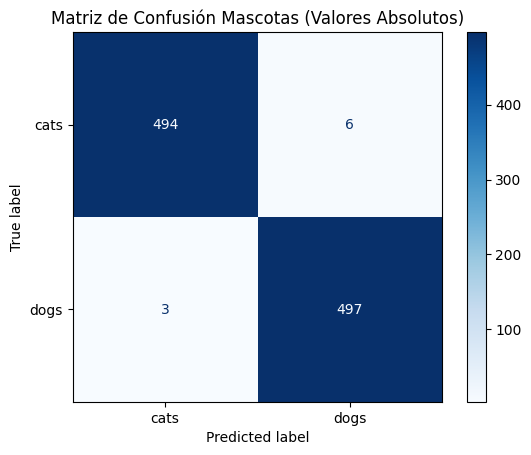

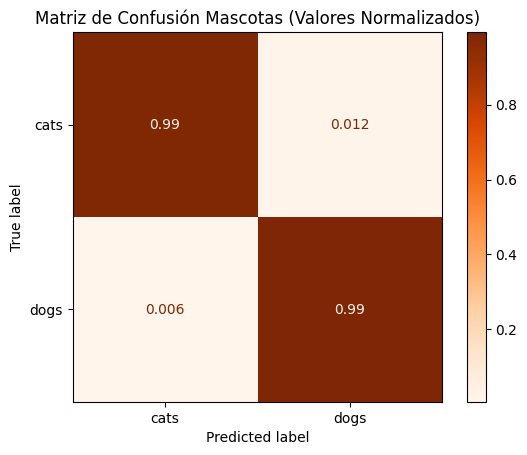

In [61]:
cm_pets = confusion_matrix(y_true_pets, y_pred_pets)
tot_pets = np.sum(cm_pets, axis=1)
cm_porc_pets = np.divide(cm_pets, np.reshape(tot_pets, (-1, 1)))

disp_pets = ConfusionMatrixDisplay(confusion_matrix=cm_pets, display_labels=nombres_clases_pets)
disp_pets.plot(cmap='Blues')
plt.title("Matriz de Confusión Mascotas (Valores Absolutos)")
plt.show()

disp_pets_norm = ConfusionMatrixDisplay(confusion_matrix=cm_porc_pets, display_labels=nombres_clases_pets)
disp_pets_norm.plot(cmap='Oranges')
plt.title("Matriz de Confusión Mascotas (Valores Normalizados)")
plt.show()

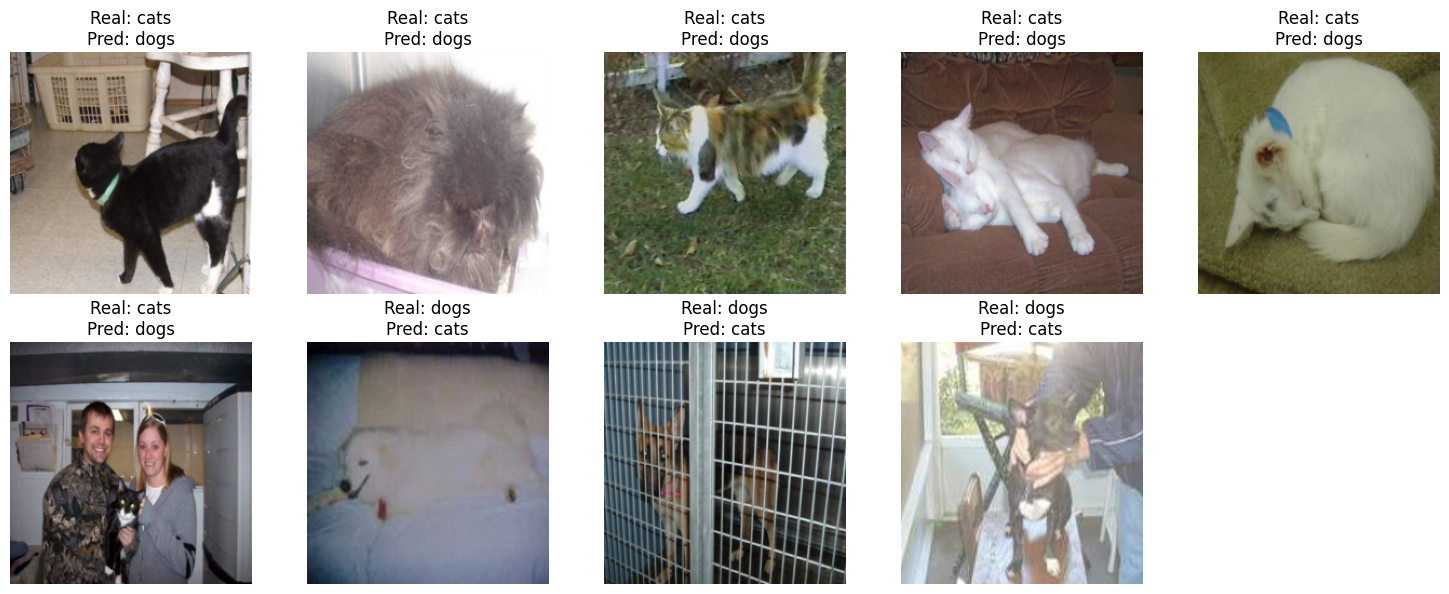

In [62]:
def graficar_muestras_mal_clasificadas(modelo, dataloader, dispositivo, nombres_clases, max_imagenes=10):
    modelo.eval()
    imagenes_error = []
    etiquetas_reales = []
    etiquetas_predichas = []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(dispositivo), labels.to(dispositivo)
            outputs = modelo(imgs)
            preds = outputs.argmax(dim=1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    imagenes_error.append(imgs[i].cpu())
                    etiquetas_reales.append(labels[i].cpu().item())
                    etiquetas_predichas.append(preds[i].cpu().item())
                    if len(imagenes_error) >= max_imagenes:
                        break
            if len(imagenes_error) >= max_imagenes:
                break

    fig = plt.figure(figsize=(15, 6))
    mean, std = modelo.get_mean_std()
    
    for idx, img in enumerate(imagenes_error):
        ax = fig.add_subplot(2, (max_imagenes + 1) // 2, idx + 1)
        img_np = img.numpy().transpose((1, 2, 0))
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0.0, 1.0)

        ax.imshow(img_np)
        ax.set_title(f"Real: {nombres_clases[etiquetas_reales[idx]]}\nPred: {nombres_clases[etiquetas_predichas[idx]]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

graficar_muestras_mal_clasificadas(modelo_resnet_eval.to(device), loader_test_pets, device, nombres_clases_pets, max_imagenes=10)

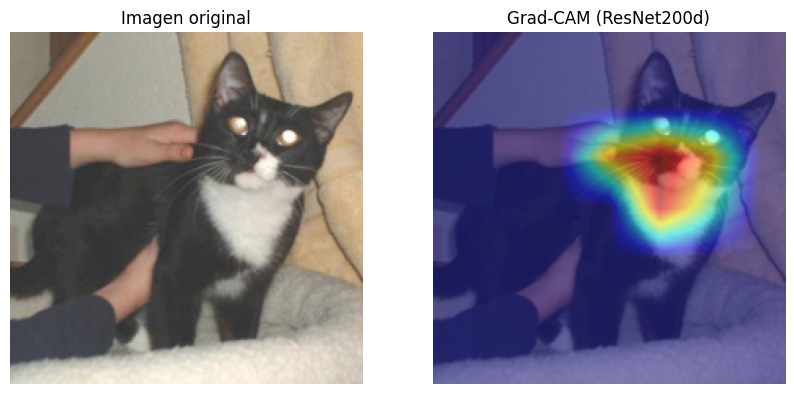

In [63]:
# ============================================================
# Visualización Grad-CAM sobre el modelo ResNet200d entrenado
# ============================================================
modelo_resnet_eval.eval()

# Capa convolucional final del backbone
# Habilitar gradientes en los parámetros para que Grad-CAM pueda calcular la retropropagación
for param in modelo_resnet_eval.parameters():
    param.requires_grad = True

target_layer_pets = modelo_resnet_eval.backbone.layer4[2].conv3
cam_pets = GradCAM(model=modelo_resnet_eval.backbone, target_layers=[target_layer_pets])

imgs, labels = next(iter(loader_test_pets))
input_tensor_pets = imgs.to(device)
grayscale_cam_pets = cam_pets(input_tensor=input_tensor_pets)[0]

# Desnormalizar imagen para visualización
mean, std = modelo_resnet_eval.get_mean_std()
img_desnorm = imgs[0].cpu().numpy().transpose(1, 2, 0)
img_desnorm = std * img_desnorm + mean
img_desnorm = np.clip(img_desnorm, 0., 1.)

cam_image_pets = show_cam_on_image(img_desnorm, grayscale_cam_pets, use_rgb=True)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen original")
plt.imshow(img_desnorm)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM (ResNet200d)")
plt.imshow(cam_image_pets)
plt.axis('off')

plt.show()